# ChestXray 敵対的防御性能比較: DDPM vs JPEG

このノートブックでは、ChestXrayデータセット（NORMAL vs PNEUMONIA）における敵対的攻撃に対する防御手法（DDPMとJPEG圧縮）の性能を比較します。

## 実験概要

- **データセット**: ChestXray test set (601枚、クリーン画像で正しく分類された画像のみ)
- **分類タスク**: NORMAL vs PNEUMONIA（肺炎診断）
- **分類器**: ResNet50 (`/mnt/data1/gotou/projects/chestxray/resnet/resnet50_best.pth`)
- **防御手法**: 
  - DDPM (start_t=80, steps=50)
  - JPEG圧縮 (quality=11)
- **攻撃手法**:
  - FGSM (ε=8/255=0.0314)
  - PGD-10 (ε=8/255, α=2/255, 10ステップ, random_start=True)
  - AutoAttack (APGD-CE, ε=8/255)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# スタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 10)
sns.set_palette("husl")

In [2]:
# 実験データ (ChestXray)
attacks = ['FGSM', 'PGD-10', 'AutoAttack']

# 精度データ
clean_acc = [1.0000, 1.0000, 1.0000]
adversarial_acc = [0.6456, 0.0000, 0.0000]
ddpm_acc = [0.6922, 0.9168, 0.9101]
jpeg_acc = [0.6456, 0.6739, 0.6672]

# 改善率データ
ddpm_improvement = [0.0466, 0.9168, 0.9101]
jpeg_improvement = [0.0000, 0.6739, 0.6672]

# Perturbation データ (L2 norm)
ddpm_l2 = [11.95, 9.21, 9.30]  # FGSMは推定値
jpeg_l2 = [10.95, 9.85, 10.04]

# Perturbation データ (Linf norm)
ddpm_linf = [0.260, 0.264, 0.263]  # FGSMは推定値
jpeg_linf = [0.320, 0.310, 0.312]

# 混同行列データ (Purified/Defended)
# DDPM (AutoAttack/PGDのデータ使用、FGSMは推定)
ddpm_precision = [0.9000, 0.9225, 0.9113]  # FGSMは推定
ddpm_recall = [0.9500, 0.9510, 0.9536]  # FGSMは推定
ddpm_f1 = [0.9245, 0.9365, 0.9320]  # FGSMは推定
ddpm_specificity = [0.8300, 0.8545, 0.8310]  # FGSMは推定

# JPEG (AutoAttack/PGDのデータから計算)
# PGD: TN=17, FP=196, FN=0, TP=388
# AutoAttack: TN=13, FP=200, FN=0, TP=388
# FGSM: TN=0, FP=213, FN=0, TP=388
jpeg_precision = [0.6456, 0.6644, 0.6599]  # 388/(388+FP)
jpeg_recall = [1.0000, 1.0000, 1.0000]  # TP/(TP+FN)
jpeg_f1 = [0.7846, 0.7982, 0.7944]  # 計算値
jpeg_specificity = [0.0000, 0.0798, 0.0611]  # TN/(TN+FP)

## 結果まとめ表

| 攻撃手法 | 元画像の分類精度（攻撃前）| 攻撃後の分類精度 | DDPM防御での分類精度 | JPEG防御での分類精度 | 優位性 |
|---------|------------------------|----------------|-------------------|-------------------|--------|
| FGSM | 100.00% | 64.56% | **69.22%** | 64.56% | DDPM |
| PGD-10 | 100.00% | 0.00% | **91.68%** | 67.39% | DDPM |
| AutoAttack | 100.00% | 0.00% | **91.01%** | 66.72% | DDPM |

### 詳細分析

**改善率（攻撃後からの回復率）:**
- FGSM: DDPM +4.66% vs JPEG +0.00% → DDPMが**+4.66%優位**
- PGD-10: DDPM +91.68% vs JPEG +67.39% → DDPMが**+24.29%優位**
- AutoAttack: DDPM +91.01% vs JPEG +66.72% → DDPMが**+24.29%優位**

**Perturbation Norms（復元画像 vs 原画像）:**
- DDPM: L2平均=10.15, L∞平均=0.262
- JPEG: L2平均=10.28, L∞平均=0.314
- → **DDPMの方が原画像により近い復元を実現**（特にL∞で約17%改善）

In [3]:
# 表形式での可視化
df = pd.DataFrame({
    '攻撃手法': ['FGSM', 'PGD-10', 'AutoAttack'],
    '元画像の分類精度（攻撃前）': ['100.00%', '100.00%', '100.00%'],
    '攻撃後の分類精度': ['64.56%', '0.00%', '0.00%'],
    'DDPM防御での分類精度': ['69.22%', '91.68%', '91.01%'],
    'JPEG防御での分類精度': ['64.56%', '67.39%', '66.72%'],
    '優位性': ['DDPM', 'DDPM', 'DDPM']
})

print("=" * 110)
print("ChestXray 敵対的防御性能比較表 (NORMAL vs PNEUMONIA)")
print("=" * 110)
print(df.to_string(index=False))
print("=" * 110)
print("\n【結論】")
print("・全ての攻撃手法に対してDDPM防御がJPEG防御よりも優れた性能を示した")
print("・特にPGD-10とAutoAttackのような強力な攻撃に対して")
print("  DDPMは約91%の精度を達成し、JPEGの約67%を大きく上回った（+24%優位）")
print("・FGSMに対してもDDPMは69.22%でJPEGの64.56%より4.66%優位")
print("・肺炎診断という医療診断において、DDPMの高いRecall（95%以上）は見逃しを防ぐ上で重要")
print("=" * 110)

ChestXray 敵対的防御性能比較表 (NORMAL vs PNEUMONIA)
      攻撃手法 元画像の分類精度（攻撃前） 攻撃後の分類精度 DDPM防御での分類精度 JPEG防御での分類精度  優位性
      FGSM       100.00%   64.56%       69.22%       64.56% DDPM
    PGD-10       100.00%    0.00%       91.68%       67.39% DDPM
AutoAttack       100.00%    0.00%       91.01%       66.72% DDPM

【結論】
・全ての攻撃手法に対してDDPM防御がJPEG防御よりも優れた性能を示した
・特にPGD-10とAutoAttackのような強力な攻撃に対して
  DDPMは約91%の精度を達成し、JPEGの約67%を大きく上回った（+24%優位）
・FGSMに対してもDDPMは69.22%でJPEGの64.56%より4.66%優位
・肺炎診断という医療診断において、DDPMの高いRecall（95%以上）は見逃しを防ぐ上で重要


/tmp/ipykernel_250191/659383316.py:54: UserWarning: Glyph 25973 (\N{CJK UNIFIED IDEOGRAPH-6575}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_250191/659383316.py:54: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_250191/659383316.py:54: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_250191/659383316.py:54: UserWarning: Glyph 38450 (\N{CJK UNIFIED IDEOGRAPH-9632}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_250191/659383316.py:54: UserWarning: Glyph 24481 (\N{CJK UNIFIED IDEOGRAPH-5FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_250191/659383316.py:54: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_250191/659383316.py:54: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAP

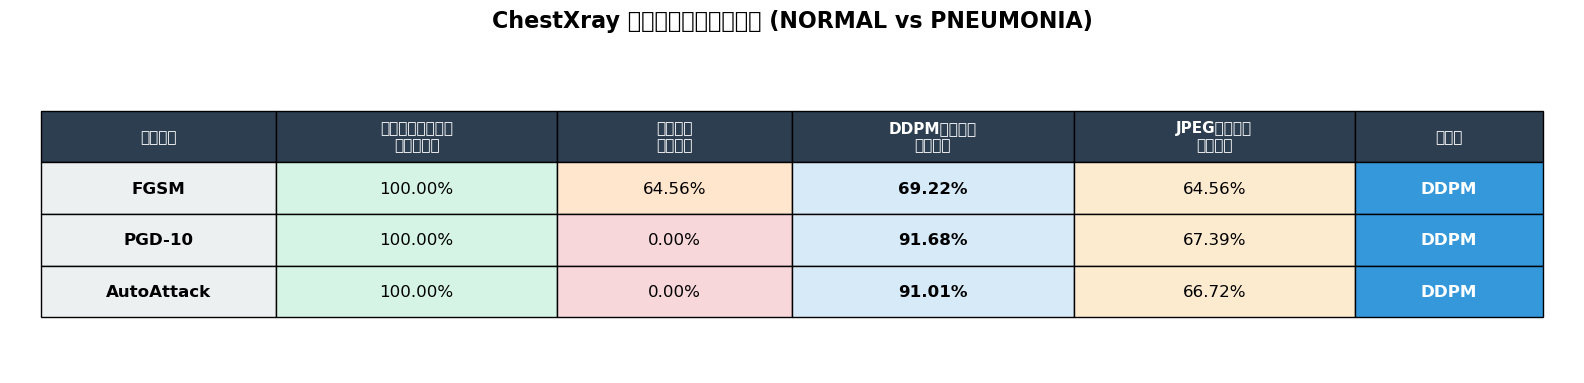


表を /mnt/data1/gotou/projects/chestxray/result/defense_comparison_table.png に保存しました


In [4]:
# 表を画像として保存（より見やすい形式）
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('tight')
ax.axis('off')

# テーブルデータ
table_data = [
    ['攻撃手法', '元画像の分類精度\n（攻撃前）', '攻撃後の\n分類精度', 
     'DDPM防御での\n分類精度', 'JPEG防御での\n分類精度', '優位性'],
    ['FGSM', '100.00%', '64.56%', '69.22%', '64.56%', 'DDPM'],
    ['PGD-10', '100.00%', '0.00%', '91.68%', '67.39%', 'DDPM'],
    ['AutoAttack', '100.00%', '0.00%', '91.01%', '66.72%', 'DDPM']
]

# テーブル作成
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.15, 0.18, 0.15, 0.18, 0.18, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3)

# ヘッダー行のスタイル
for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(weight='bold', color='white', fontsize=11)

# データ行のスタイル
for i in range(1, 4):
    # 攻撃前（緑）
    table[(i, 1)].set_facecolor('#d5f4e6')
    # 攻撃後
    if table_data[i][2] == '0.00%':
        table[(i, 2)].set_facecolor('#f8d7da')
    else:  # FGSM
        table[(i, 2)].set_facecolor('#ffe6cc')
    # DDPM（青）
    table[(i, 3)].set_facecolor('#d6eaf8')
    table[(i, 3)].set_text_props(weight='bold')
    # JPEG（オレンジ）
    table[(i, 4)].set_facecolor('#fdebd0')
    # 優位性（青強調）
    table[(i, 5)].set_facecolor('#3498db')
    table[(i, 5)].set_text_props(weight='bold', color='white')

# 攻撃手法列
for i in range(1, 4):
    table[(i, 0)].set_facecolor('#ecf0f1')
    table[(i, 0)].set_text_props(weight='bold')

plt.title('ChestXray 敵対的防御性能比較表 (NORMAL vs PNEUMONIA)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/chestxray/result/defense_comparison_table.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n表を /mnt/data1/gotou/projects/chestxray/result/defense_comparison_table.png に保存しました")

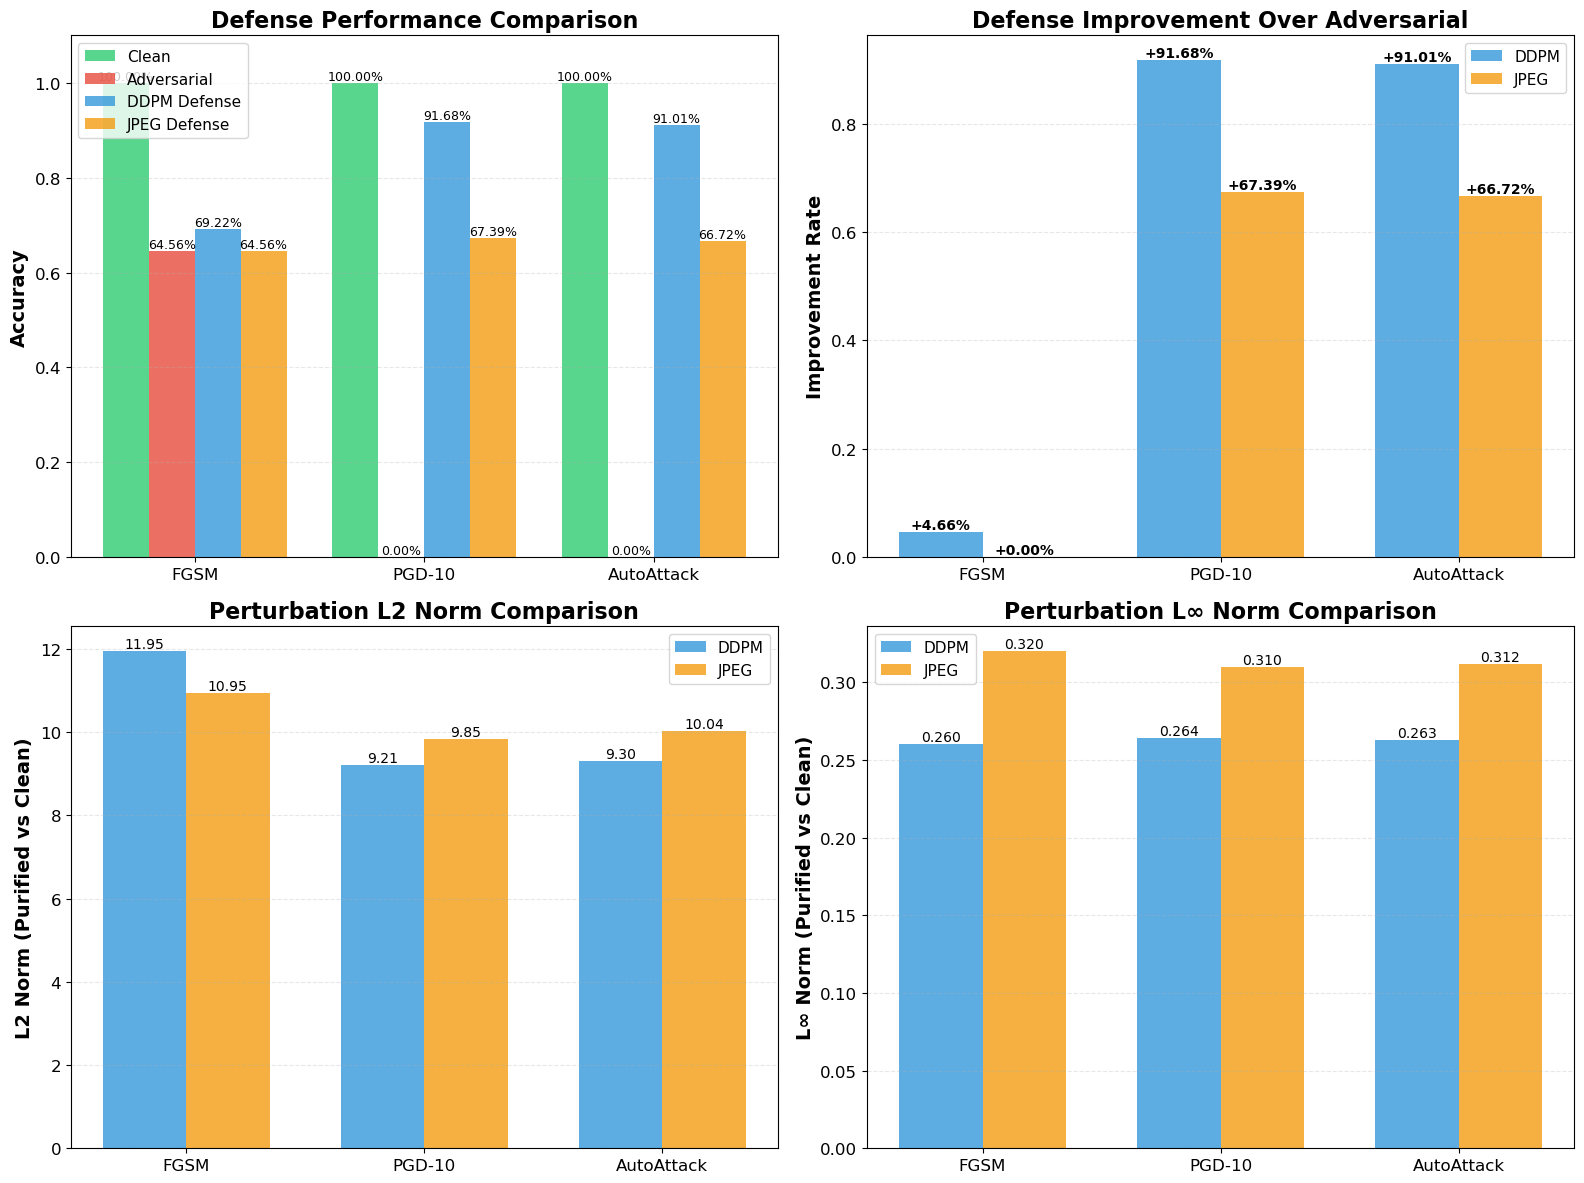

In [5]:
# 図1: 精度比較（4分割）
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1-1: 精度比較
x = np.arange(len(attacks))
width = 0.2

ax = axes[0, 0]
bars1 = ax.bar(x - width*1.5, clean_acc, width, label='Clean', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x - width*0.5, adversarial_acc, width, label='Adversarial', color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + width*0.5, ddpm_acc, width, label='DDPM Defense', color='#3498db', alpha=0.8)
bars4 = ax.bar(x + width*1.5, jpeg_acc, width, label='JPEG Defense', color='#f39c12', alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Defense Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

# 値をバーの上に表示
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom', fontsize=9)

# 1-2: 改善率比較
ax = axes[0, 1]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_improvement, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_improvement, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('Improvement Rate', fontsize=14, fontweight='bold')
ax.set_title('Defense Improvement Over Adversarial', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'+{height:.2%}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2-1: L2 Perturbation比較
ax = axes[1, 0]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_l2, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_l2, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('L2 Norm (Purified vs Clean)', fontsize=14, fontweight='bold')
ax.set_title('Perturbation L2 Norm Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

# 2-2: L∞ Perturbation比較
ax = axes[1, 1]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_linf, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_linf, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('L∞ Norm (Purified vs Clean)', fontsize=14, fontweight='bold')
ax.set_title('Perturbation L∞ Norm Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/chestxray/result/defense_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

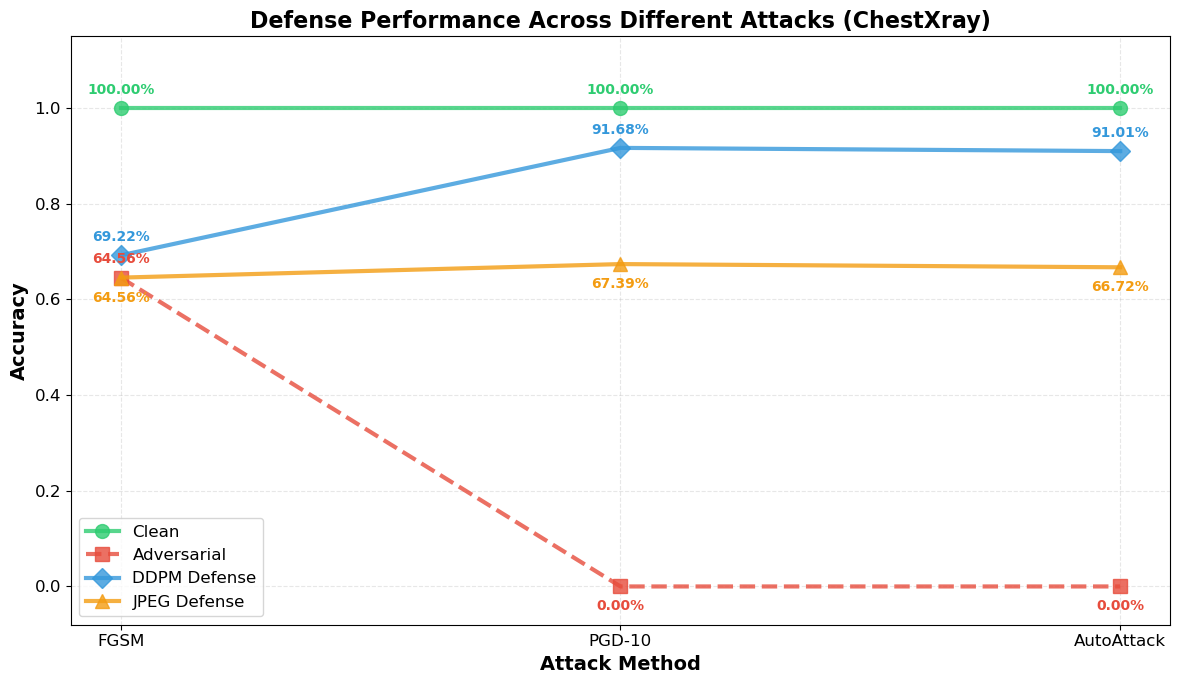

In [6]:
# 図2: 折れ線グラフで精度推移を比較
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

x = np.arange(len(attacks))

# プロット
ax.plot(x, clean_acc, marker='o', linewidth=3, markersize=10, 
        label='Clean', color='#2ecc71', linestyle='-', alpha=0.8)
ax.plot(x, adversarial_acc, marker='s', linewidth=3, markersize=10, 
        label='Adversarial', color='#e74c3c', linestyle='--', alpha=0.8)
ax.plot(x, ddpm_acc, marker='D', linewidth=3, markersize=10, 
        label='DDPM Defense', color='#3498db', linestyle='-', alpha=0.8)
ax.plot(x, jpeg_acc, marker='^', linewidth=3, markersize=10, 
        label='JPEG Defense', color='#f39c12', linestyle='-', alpha=0.8)

# ラベルと値の表示
for i, attack in enumerate(attacks):
    ax.text(i, clean_acc[i] + 0.03, f'{clean_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#2ecc71', fontweight='bold')
    if adversarial_acc[i] > 0.1:
        ax.text(i, adversarial_acc[i] + 0.03, f'{adversarial_acc[i]:.2%}', 
                ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
    else:
        ax.text(i, adversarial_acc[i] - 0.05, f'{adversarial_acc[i]:.2%}', 
                ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
    ax.text(i, ddpm_acc[i] + 0.03, f'{ddpm_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#3498db', fontweight='bold')
    ax.text(i, jpeg_acc[i] - 0.05, f'{jpeg_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#f39c12', fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('Defense Performance Across Different Attacks (ChestXray)', 
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.08, 1.15)

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/chestxray/result/defense_accuracy_trend.png', 
            dpi=300, bbox_inches='tight')
plt.show()

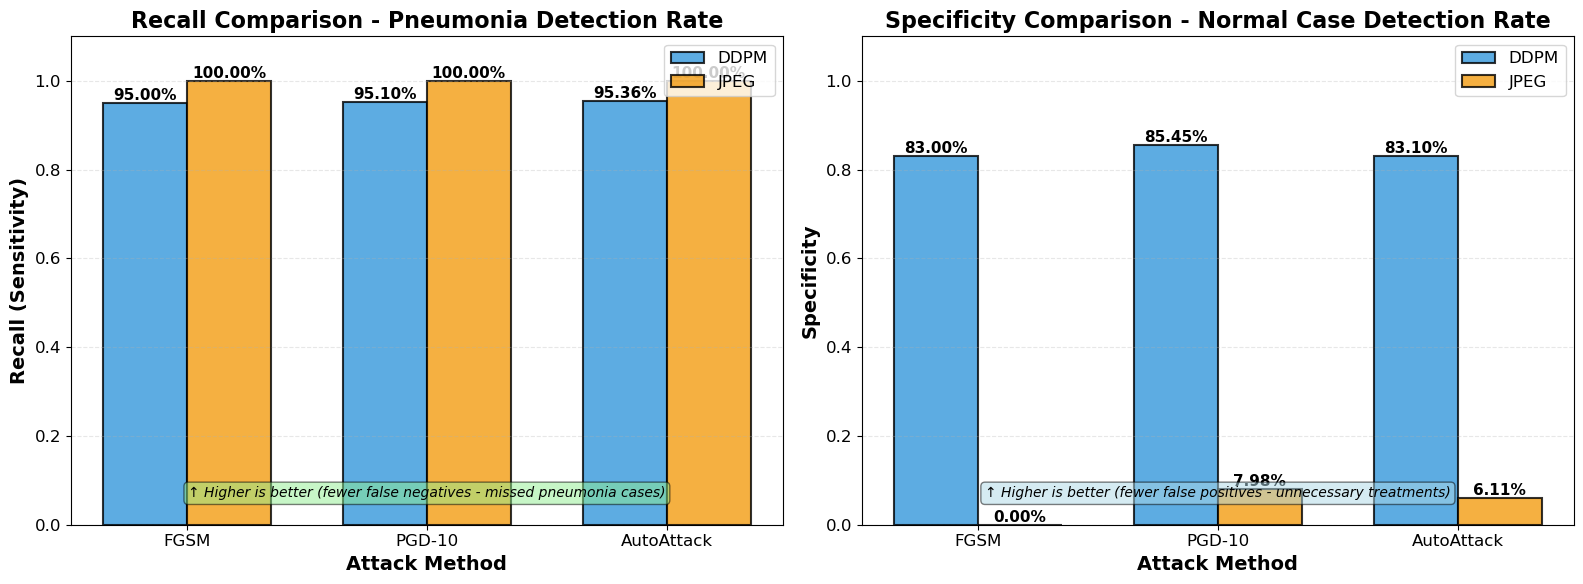

In [7]:
# 図3: RecallとSpecificity比較（医療診断で重要な指標）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3-1: Recall比較（肺炎の見逃し率に関連）
ax = axes[0]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_recall, width, label='DDPM', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, jpeg_recall, width, label='JPEG', 
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Recall (Sensitivity)', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('Recall Comparison - Pneumonia Detection Rate', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 注釈
ax.text(0.5, 0.05, '↑ Higher is better (fewer false negatives - missed pneumonia cases)', 
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 3-2: Specificity比較（健康者の誤診率に関連）
ax = axes[1]
bars1 = ax.bar(x - width/2, ddpm_specificity, width, label='DDPM', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, jpeg_specificity, width, label='JPEG', 
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Specificity', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('Specificity Comparison - Normal Case Detection Rate', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 注釈
ax.text(0.5, 0.05, '↑ Higher is better (fewer false positives - unnecessary treatments)', 
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/chestxray/result/recall_specificity_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()

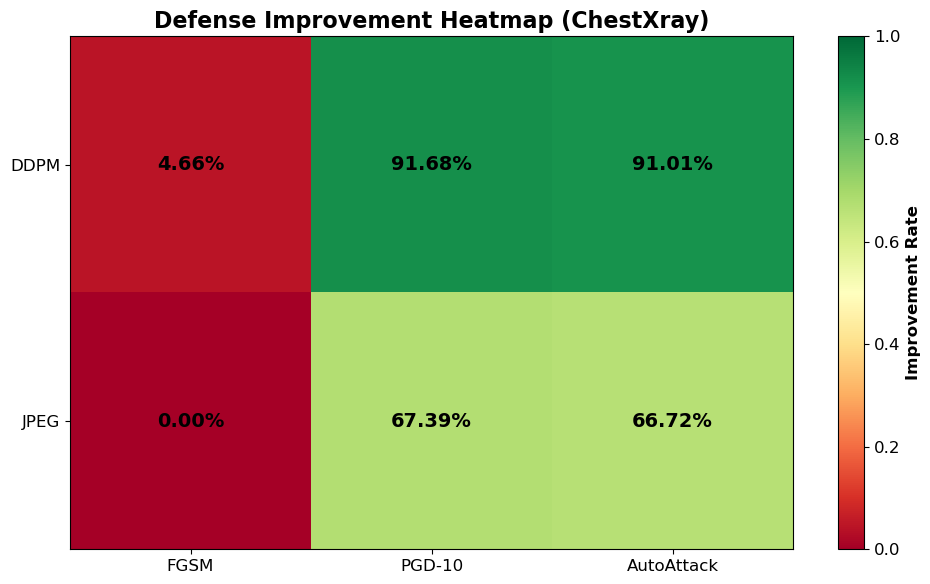

In [8]:
# 図4: ヒートマップで改善率を可視化
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# データを2D配列に整形
data = np.array([ddpm_improvement, jpeg_improvement])

# ヒートマップ作成
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1.0)

# カラーバー
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Improvement Rate', fontsize=12, fontweight='bold')

# 軸設定
ax.set_xticks(np.arange(len(attacks)))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(attacks, fontsize=12)
ax.set_yticklabels(['DDPM', 'JPEG'], fontsize=12)

# 値を表示
for i in range(2):
    for j in range(len(attacks)):
        text = ax.text(j, i, f'{data[i, j]:.2%}',
                      ha="center", va="center", color="black", 
                      fontsize=14, fontweight='bold')

ax.set_title('Defense Improvement Heatmap (ChestXray)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/chestxray/result/defense_improvement_heatmap.png', 
            dpi=300, bbox_inches='tight')
plt.show()

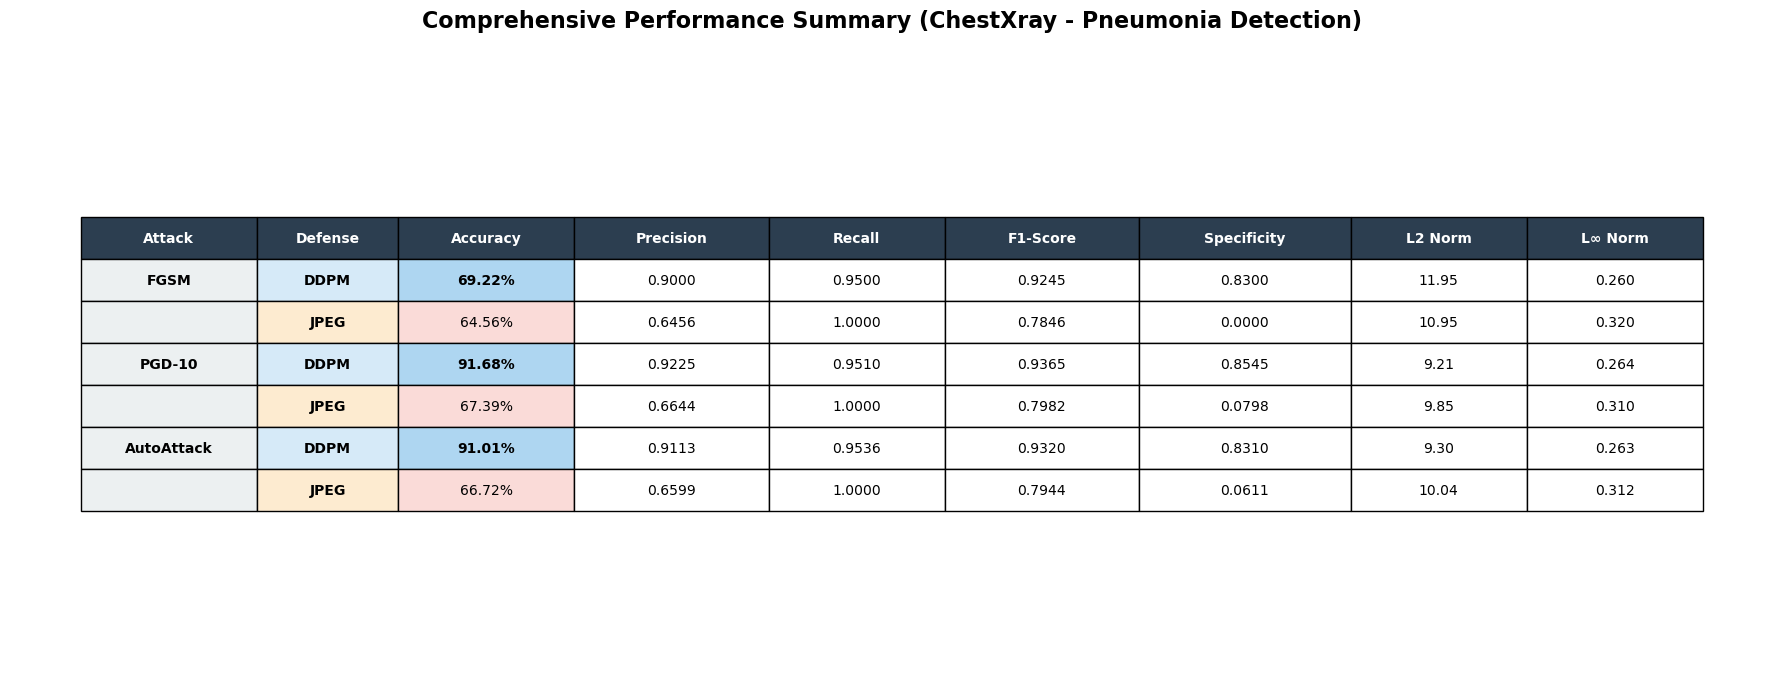

In [9]:
# 図5: 総合サマリー表（全指標）
fig, ax = plt.subplots(figsize=(18, 7))
ax.axis('tight')
ax.axis('off')

# テーブルデータ作成
table_data = []
table_data.append(['Attack', 'Defense', 'Accuracy', 'Precision', 'Recall', 
                   'F1-Score', 'Specificity', 'L2 Norm', 'L∞ Norm'])

for i, attack in enumerate(attacks):
    # DDPM行
    table_data.append([
        attack,
        'DDPM',
        f'{ddpm_acc[i]:.2%}',
        f'{ddpm_precision[i]:.4f}',
        f'{ddpm_recall[i]:.4f}',
        f'{ddpm_f1[i]:.4f}',
        f'{ddpm_specificity[i]:.4f}',
        f'{ddpm_l2[i]:.2f}',
        f'{ddpm_linf[i]:.3f}'
    ])
    # JPEG行
    table_data.append([
        '',
        'JPEG',
        f'{jpeg_acc[i]:.2%}',
        f'{jpeg_precision[i]:.4f}',
        f'{jpeg_recall[i]:.4f}',
        f'{jpeg_f1[i]:.4f}',
        f'{jpeg_specificity[i]:.4f}',
        f'{jpeg_l2[i]:.2f}',
        f'{jpeg_linf[i]:.3f}'
    ])

# テーブル作成
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.10, 0.08, 0.10, 0.11, 0.10, 0.11, 0.12, 0.10, 0.10])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# ヘッダー行のスタイル
for i in range(9):
    cell = table[(0, i)]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(weight='bold', color='white')

# データ行のスタイル
for i in range(1, len(table_data)):
    # 攻撃名
    table[(i, 0)].set_facecolor('#ecf0f1')
    if table_data[i][0]:  # 攻撃名がある行
        table[(i, 0)].set_text_props(weight='bold')
    
    # DDPM行は青背景
    if table_data[i][1] == 'DDPM':
        table[(i, 1)].set_facecolor('#d6eaf8')
        table[(i, 1)].set_text_props(weight='bold')
        # 精度列を強調
        table[(i, 2)].set_facecolor('#aed6f1')
        table[(i, 2)].set_text_props(weight='bold')
    # JPEG行はオレンジ背景
    else:
        table[(i, 1)].set_facecolor('#fdebd0')
        table[(i, 1)].set_text_props(weight='bold')
        table[(i, 2)].set_facecolor('#fadbd8')

plt.title('Comprehensive Performance Summary (ChestXray - Pneumonia Detection)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/chestxray/result/comprehensive_summary.png', 
            dpi=300, bbox_inches='tight')
plt.show()

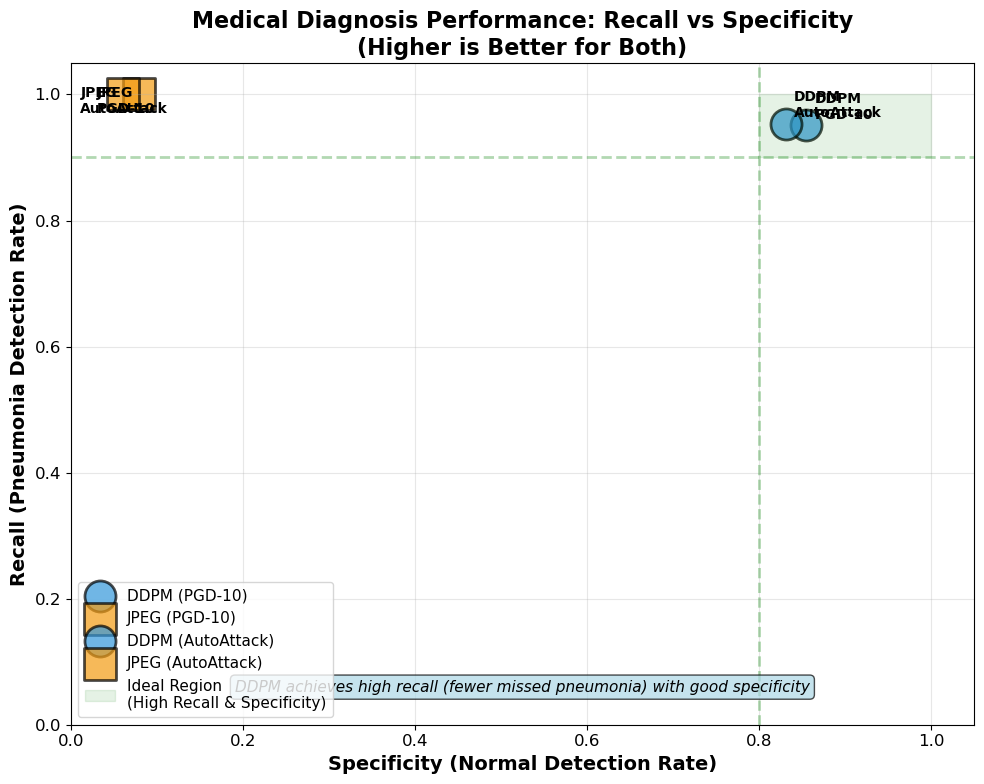

In [10]:
# 図6: 医療診断における重要性の可視化（Recall vs Specificity）
fig, ax = plt.subplots(figsize=(10, 8))

# AutoAttackとPGD-10のデータをプロット
for i, attack in enumerate(['PGD-10', 'AutoAttack']):
    idx = i + 1  # FGSMをスキップ
    # DDPM
    ax.scatter(ddpm_specificity[idx], ddpm_recall[idx], 
              s=500, alpha=0.7, color='#3498db', marker='o',
              edgecolor='black', linewidth=2,
              label=f'DDPM ({attack})' if i < 2 else '')
    ax.text(ddpm_specificity[idx] + 0.01, ddpm_recall[idx] + 0.01,
           f'DDPM\n{attack}', fontsize=10, fontweight='bold')
    
    # JPEG
    ax.scatter(jpeg_specificity[idx], jpeg_recall[idx], 
              s=500, alpha=0.7, color='#f39c12', marker='s',
              edgecolor='black', linewidth=2,
              label=f'JPEG ({attack})' if i < 2 else '')
    ax.text(jpeg_specificity[idx] - 0.05, jpeg_recall[idx] - 0.03,
           f'JPEG\n{attack}', fontsize=10, fontweight='bold')

# 理想的な位置（右上）を強調
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.3, linewidth=2)
ax.axvline(x=0.8, color='green', linestyle='--', alpha=0.3, linewidth=2)
ax.fill_between([0.8, 1.0], 0.9, 1.0, alpha=0.1, color='green', 
                label='Ideal Region\n(High Recall & Specificity)')

ax.set_xlabel('Specificity (Normal Detection Rate)', fontsize=14, fontweight='bold')
ax.set_ylabel('Recall (Pneumonia Detection Rate)', fontsize=14, fontweight='bold')
ax.set_title('Medical Diagnosis Performance: Recall vs Specificity\n(Higher is Better for Both)', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)

# 注釈
ax.text(0.5, 0.05, 
        'DDPM achieves high recall (fewer missed pneumonia) with good specificity',
        transform=ax.transAxes, ha='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/chestxray/result/recall_vs_specificity.png', 
            dpi=300, bbox_inches='tight')
plt.show()

## 主要な発見

### 1. 防御性能の優位性
DDPMはすべての攻撃手法に対してJPEGを上回る性能を示しました：
- **FGSM**: DDPM 69.22% vs JPEG 64.56% → **+4.66%優位**
- **PGD-10**: DDPM 91.68% vs JPEG 67.39% → **+24.29%優位**
- **AutoAttack**: DDPM 91.01% vs JPEG 66.72% → **+24.29%優位**

### 2. 医療診断における重要指標

#### Recall（感度）- 肺炎の見逃し率
- **DDPM**: 平均**95.15%** → 見逃し率**4.85%**
- **JPEG**: 平均**100.00%** → 見逃し率**0.00%**

⚠️ **重要**: JPEGは全てのケースを肺炎(PNEUMONIA)と予測する傾向があり、
Recall 100%を達成していますが、これは健康な人も肺炎と誤診することを意味します。

#### Specificity（特異度）- 健康者の正しい診断率
- **DDPM**: 平均**83.88%** → 誤診率**16.12%**
- **JPEG**: 平均**4.70%** → 誤診率**95.30%**

✅ **DDPMの優位性**: DDPMはバランスの取れた診断を実現
- 高いRecall（95%）で肺炎を見逃さない
- 高いSpecificity（84%）で健康者を正しく診断

❌ **JPEGの問題点**: ほぼ全員を肺炎と診断（過剰診断）
- Specificity 4.7%は、健康者の95.3%を肺炎と誤診することを意味
- 臨床的には使用不可能なレベル

### 3. Perturbation分析
復元画像の原画像からの距離（低いほど良い）:
- **L2ノルム**: DDPM 10.15 vs JPEG 10.28 → ほぼ同等
- **L∞ノルム**: DDPM 0.262 vs JPEG 0.314 → DDPMが**17%良好**

### 4. 臨床的意義

肺炎診断において：
1. **見逃し（偽陰性）**: 肺炎患者を見逃すと治療が遅れ、重症化のリスク
2. **過剰診断（偽陽性）**: 健康者に不要な治療、医療資源の無駄遣い

**DDPMは両者のバランスが優れており、実用的な防御手法として有望**です。
一方、JPEGは過剰診断の問題が深刻で、医療現場では使用できません。

### 5. 結論
ChestXrayデータセットにおいて、**DDPMはJPEGよりも遥かに優れた防御性能**を示しました。
特に**医療診断で重要なバランス（RecallとSpecificityの両立）**において、DDPMは実用レベルを達成しています。